# 06 · Selection can reward a shortcut

## Goal
Inspect a deliberately constructed search example. It is RRSI-inspired design practice, not a paper replication.

**Status:** worked example prepared by Codex; learner understanding unassessed. No API calls.

## Setup
Run top to bottom. All examples are synthetic unless explicitly labelled as public evidence.

In [1]:
from pathlib import Path
import sys, json, tempfile
ROOT = Path.cwd()
if ROOT.name == 'notebooks': ROOT = ROOT.parent
assert (ROOT / 'signal_lab').is_dir(), 'Run from the companion root or notebooks directory'
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.figsize': (8, 4.2), 'font.size': 11, 'axes.spines.top': False, 'axes.spines.right': False})


## Steps

### 1. Inspect all candidate changes before seeing selection

In [2]:
from signal_lab.evolution import compare
e=compare()
pd.DataFrame(e['candidates'])

,id,hypothesis,edits,complexity,benchmark_specific
0,base,Use surface label,(),0,False
1,memorize,Memorize development task identifiers,"(task-id shortcut,)",1,True
2,check-evidence,Resolve labels from available evidence,"(read evidence,)",1,False
3,extra-review,Recheck every answer,"(read evidence, duplicate review)",2,False


### 2. Compare the frozen rule and two selectors

In [3]:
results=pd.DataFrame(e['results']);results

,method,candidate,development_accuracy,transfer_accuracy,complexity,search_candidates
0,frozen,base,0.5,0.5,0,0
1,unregularized,memorize,1.0,0.5,1,3
2,regularized-inspired,check-evidence,1.0,1.0,1,3


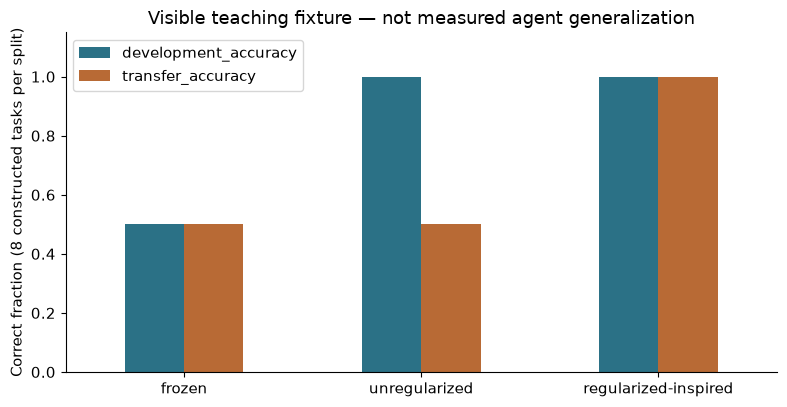

In [4]:
ax=results.set_index('method')[['development_accuracy','transfer_accuracy']].plot.bar(color=['#2b7186','#b86a35'])
ax.set(ylim=(0,1.15),ylabel='Correct fraction (8 constructed tasks per split)',xlabel='',title='Visible teaching fixture — not measured agent generalization')
plt.xticks(rotation=0);plt.tight_layout();plt.show()

The lookup shortcut wins the unregularized tie-break; screening it selects a reusable evidence rule. Extra review adds complexity without changing these constructed answers. Real pruning must account for interactions and noise.

In [5]:
print(e['transfer_status'])
print('Paper mechanisms not implemented:', ', '.join(e['unimplemented_paper_features']))

visible and consumed; not a blinded holdout
Paper mechanisms not implemented: model-generated edits, shrinking edit budget, novelty search, statistical selection, interaction-aware pruning


## Checks
Both search methods inspect the same candidate shortlist. Transfer fixtures are visible and consumed. No stochastic variability can be estimated from identical deterministic reruns.

## Next Steps
Optional: suggest a case where the extra review could matter. A live comparison needs fresh isolated tasks, a fixed backbone and matched search budgets.

**Low energy:** stop here. The checkpoint is optional; reading the worked output does not update mastery.